<a href="https://colab.research.google.com/github/HariniAnandkumar/neuromorphic-ai-research/blob/main/04_robustness_fmnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install snntorch -q  # snnTorch isn't preinstalled on Colab; -q = quiet

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import snntorch as snn          # spiking-neuron layers (LIF)
from torch.optim.lr_scheduler import StepLR

import time
import os
import pandas as pd

# Use the GPU if Colab gave us one; SNNs are slow on CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 5.5 MB/s eta 0:00:00
Device: cuda
GPU: Tesla T4


In [ ]:
# Fashion-MNIST: 28x28 grayscale clothing images, 10 classes.
# ToTensor() converts PIL images to tensors with pixel values in [0, 1].
transform = transforms.ToTensor()

# train=True  -> 60,000 images for training
trainset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
# train=False -> 10,000 held-out images, never seen during training
testset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

# shuffle=True on train so batch order changes each epoch (helps learning)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
# shuffle=False on test so results are reproducible
testloader  = torch.utils.data.DataLoader(testset,  batch_size=128, shuffle=False)

print("Train images:", len(trainset), "| Test images:", len(testset))

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.91MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.93MB/s]


Train images: 60000 | Test images: 10000


In [ ]:
# All 3 architectures use the SAME conv/linear shapes, so their
# parameter counts match. Only the neuron type / spiking differs.

num_steps = 10   # how many timesteps the SNN/Hybrid run per image
beta = 0.95      # LIF membrane decay: closer to 1 = remembers inputs longer

# ---- ANN: plain CNN, no spikes ----
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, 3), nn.ReLU(),     # 1 input channel -> 32 feature maps
            nn.Conv2d(32, 64, 3), nn.ReLU(),    # 32 -> 64 feature maps
            nn.MaxPool2d(2),                    # halve spatial size
            nn.Dropout(0.25),                   # regularization, train-time only
            nn.Flatten(),
            nn.Linear(9216, 128), nn.ReLU(),
            nn.Linear(128, 10),                 # 10 outputs = 10 classes
        )
    def forward(self, x):
        return self.model(x)

# ---- SNN: fully spiking, LIF neurons after every layer ----
class SNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.lif1  = snn.Leaky(beta=beta)       # spiking neuron after conv1
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.lif2  = snn.Leaky(beta=beta)
        self.pool  = nn.MaxPool2d(2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(9216, 128)
        self.lif3 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(128, 10)
        self.lif4 = snn.Leaky(beta=beta)

    def forward(self, x):
        # Reset every neuron's membrane potential at the start of each image.
        # Skipping this leaks state between samples — a common SNN bug.
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()

        spk4_rec = []  # collect output spikes from every timestep

        # Run the network for num_steps; neurons integrate input over time
        for step in range(num_steps):
            cur1 = self.conv1(x)
            spk1, mem1 = self.lif1(cur1, mem1)   # returns (spikes, new membrane)
            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            pooled = self.pool(spk2)
            flat = self.flatten(pooled)
            cur3 = self.fc1(flat)
            spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.fc2(spk3)
            spk4, mem4 = self.lif4(cur4, mem4)
            spk4_rec.append(spk4)

        # Stack into [num_steps, batch, 10]. Robustness only needs the output.
        return torch.stack(spk4_rec)

# ---- Hybrid: ANN conv front-end + spiking classifier head ----
class Hybrid(nn.Module):
    def __init__(self):
        super().__init__()
        # ANN feature extractor (non-spiking)
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.relu2 = nn.ReLU()
        self.pool  = nn.MaxPool2d(2)
        self.flatten = nn.Flatten()
        # Spiking classifier head
        self.fc1 = nn.Linear(9216, 128)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(128, 10)
        self.lif2 = snn.Leaky(beta=beta)

    def forward(self, x):
        # ANN part: runs ONCE, extracts spatial features
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.pool(x)
        x = self.flatten(x)

        # Spiking part: runs over num_steps timesteps
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec = []
        for step in range(num_steps):
            # x is the same each step (direct input encoding) — the
            # spiking head still evolves because membrane potential carries over
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
        return torch.stack(spk2_rec)

print("Model classes defined.")

Model classes defined.


In [ ]:
# Each function corrupts a batch of images. Images are floats in [0, 1].
# 'severity' means something different per noise type — see SEVERITY below.

def add_gaussian(images, severity):
    """Add random Gaussian noise. severity = standard deviation."""
    noise = torch.randn_like(images) * severity   # random values, scaled by severity
    noisy = images + noise
    # clamp back to [0,1] so noisy images stay in the trained input range
    return torch.clamp(noisy, 0.0, 1.0)

def add_salt_pepper(images, severity):
    """Flip a fraction of pixels to pure white or black.
    severity = fraction of pixels corrupted (0.0 to 1.0)."""
    noisy = images.clone()                        # don't modify the original
    rand = torch.rand_like(images)                # one random number per pixel
    noisy[rand < (severity / 2)] = 1.0            # lowest-rolling pixels -> white (salt)
    noisy[(rand >= (severity / 2)) & (rand < severity)] = 0.0  # next group -> black (pepper)
    return noisy

def add_occlusion(images, severity):
    """Black out a square patch at a random location.
    severity = side length of the patch in pixels."""
    noisy = images.clone()
    b, c, h, w = noisy.shape
    size = int(severity)
    if size <= 0:
        return noisy
    for i in range(b):  # each image gets its patch in a different random spot
        # randint upper bound keeps the whole patch inside the image
        top  = torch.randint(0, max(1, h - size + 1), (1,)).item()
        left = torch.randint(0, max(1, w - size + 1), (1,)).item()
        noisy[i, :, top:top+size, left:left+size] = 0.0
    return noisy

# Severity levels per noise type. Numbers differ because 'severity' has a
# different meaning for each (std vs fraction vs pixels) — so we compare a
# model against ITSELF across a noise type, never one noise type to another.
SEVERITY = {
    "clean":       [0.0],
    "gaussian":    [0.1, 0.2, 0.3, 0.4, 0.5],       # noise standard deviation
    "salt_pepper": [0.05, 0.10, 0.15, 0.20, 0.25],  # fraction of pixels flipped
    "occlusion":   [4, 8, 12, 16, 20],              # patch side length in pixels
}

print("Noise functions defined.")

Noise functions defined.


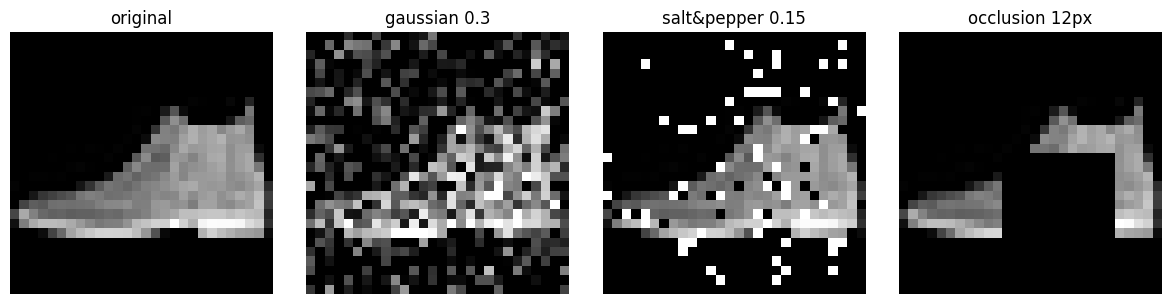

In [ ]:
# Sanity check: SEE the noise on one image before the long run.
# Not part of the experiment — run it once and confirm it looks right.
import matplotlib.pyplot as plt

sample, _ = testset[0]
sample = sample.unsqueeze(0)  # add batch dimension -> shape [1,1,28,28]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(sample[0,0], cmap="gray"); axes[0].set_title("original")
axes[1].imshow(add_gaussian(sample, 0.3)[0,0], cmap="gray"); axes[1].set_title("gaussian 0.3")
axes[2].imshow(add_salt_pepper(sample, 0.15)[0,0], cmap="gray"); axes[2].set_title("salt&pepper 0.15")
axes[3].imshow(add_occlusion(sample, 12)[0,0], cmap="gray"); axes[3].set_title("occlusion 12px")
for a in axes: a.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
def train_model(model, seed):
    """Train a model for 15 epochs and return it."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = StepLR(optimizer, step_size=5, gamma=0.5)  # halve LR every 5 epochs

    for epoch in range(15):
        model.train()
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()                # clear old gradients
            out = model(images)
            # SNN/Hybrid return [steps, batch, 10]; sum spikes over time.
            # ANN returns [batch, 10] already, so we leave it alone.
            if out.dim() == 3:
                out = out.sum(dim=0)
            loss = criterion(out, labels)
            loss.backward()                      # compute gradients
            optimizer.step()                     # update weights
        scheduler.step()
    return model


def evaluate_under_noise(model, noise_fn, severity):
    """Apply a noise function to the test set, return accuracy %."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():                        # no gradients needed for evaluation
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            if noise_fn is not None:             # None = clean baseline, no noise
                images = noise_fn(images, severity)
            out = model(images)
            if out.dim() == 3:
                out = out.sum(dim=0)
            _, predicted = torch.max(out, 1)     # class with highest score
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100.0 * correct / total

In [ ]:
# For each seed: train all 3 models fresh, then test each on clean data
# plus every noise type and severity. Results saved to CSV after each
# seed, so a Colab disconnect only costs the seed in progress.

SEEDS = [0, 1, 2,]                          # 3 seeds -> error bars
RESULTS_CSV = "robustness_results.csv"

NOISE_FNS = {                                    # None for clean = no corruption
    "clean": None,
    "gaussian": add_gaussian,
    "salt_pepper": add_salt_pepper,
    "occlusion": add_occlusion,
}
MODEL_CLASSES = {"ANN": ANN, "SNN": SNN, "Hybrid": Hybrid}

# Resume support: if the CSV exists, skip seeds already finished.
if os.path.exists(RESULTS_CSV):
    done_df = pd.read_csv(RESULTS_CSV)
    seeds_done = set(done_df["seed"].unique())
    print("Found existing results. Seeds already done:", seeds_done)
else:
    seeds_done = set()

for seed in SEEDS:
    if seed in seeds_done:
        print(f"Seed {seed} already done — skipping.")
        continue

    print(f"\n===== SEED {seed} =====")
    seed_start = time.time()
    rows = []                                    # this seed's results

    for model_name, ModelClass in MODEL_CLASSES.items():
        # Set the seed right before building each model so the only
        # thing varying between runs is this number.
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        print(f"  Training {model_name} ...")
        model = ModelClass().to(device)
        model = train_model(model, seed)

        # Test this trained model on clean + every noise type/severity
        for noise_name, noise_fn in NOISE_FNS.items():
            for sev in SEVERITY[noise_name]:
                acc = evaluate_under_noise(model, noise_fn, sev)
                rows.append({
                    "seed": seed,
                    "model": model_name,
                    "noise_type": noise_name,
                    "severity": sev,
                    "accuracy": acc,
                })
        print(f"  {model_name} done.")

    # Append this seed to the CSV immediately (write header only once)
    seed_df = pd.DataFrame(rows)
    if os.path.exists(RESULTS_CSV):
        seed_df.to_csv(RESULTS_CSV, mode="a", header=False, index=False)
    else:
        seed_df.to_csv(RESULTS_CSV, index=False)

    mins = (time.time() - seed_start) / 60
    print(f"Seed {seed} finished and saved ({mins:.1f} min).")

print("\nAll seeds complete. Results in", RESULTS_CSV)


===== SEED 0 =====
  Training ANN ...
  ANN done.
  Training SNN ...
  SNN done.
  Training Hybrid ...
  Hybrid done.
Seed 0 finished and saved (19.8 min).

===== SEED 1 =====
  Training ANN ...
  ANN done.
  Training SNN ...
  SNN done.
  Training Hybrid ...
  Hybrid done.
Seed 1 finished and saved (19.8 min).

===== SEED 2 =====
  Training ANN ...
  ANN done.
  Training SNN ...
  SNN done.
  Training Hybrid ...
  Hybrid done.
Seed 2 finished and saved (19.8 min).

All seeds complete. Results in robustness_results.csv


In [ ]:
df = pd.read_csv(RESULTS_CSV)
print("Total rows:", len(df))
print("Seeds:", sorted(df["seed"].unique()))

# Clean accuracy averaged across seeds, with standard deviation
clean = df[df["noise_type"] == "clean"]
summary = clean.groupby("model")["accuracy"].agg(["mean", "std"])
print("\nClean accuracy (mean +/- std across seeds):")
print(summary)

Total rows: 144
Seeds: [np.int64(0), np.int64(1), np.int64(2)]

Clean accuracy (mean +/- std across seeds):
             mean       std
model                      
ANN     92.796667  0.146401
Hybrid  92.793333  0.047258
SNN     92.036667  0.165025
